In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shared import colors, init_plt

In [2]:
init_plt()
df = pd.read_csv('../../data/noisy-neighbors.csv')
num_neighbors = df['num_neighbors'].unique()

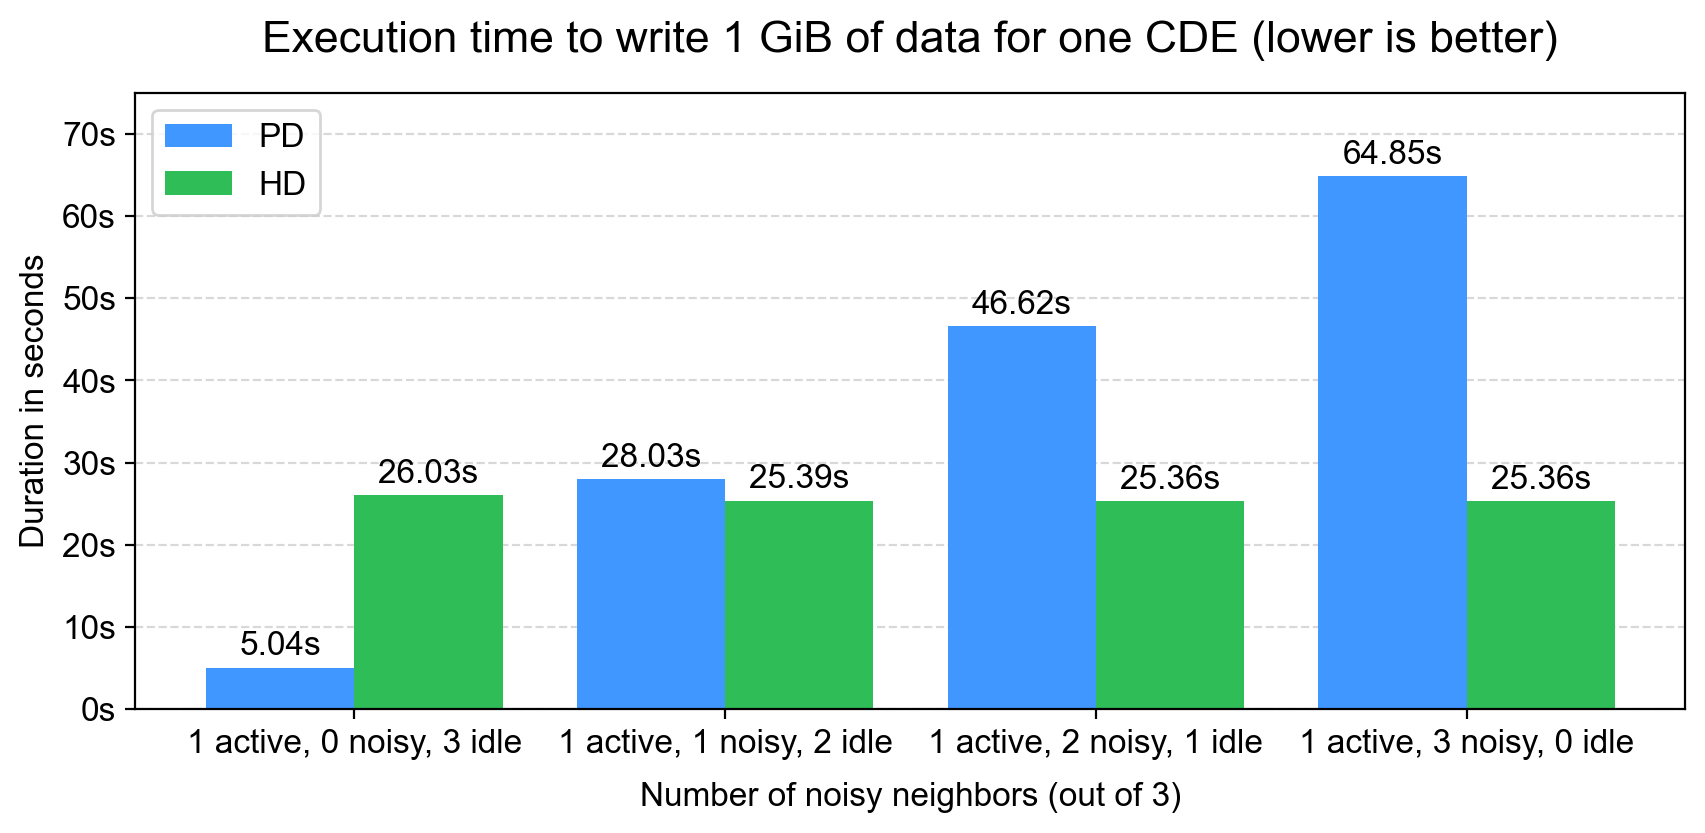

In [3]:
ax: plt.Axes
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4), dpi=200)

plt.title("Execution time to write 1 GiB of data for one CDE (lower is better)", pad=15, size=16)
ax.set_axisbelow(True)

if "x_axis":
    cases = np.arange(len(num_neighbors))
    ax.set_xticks(cases, ['1 active, 0 noisy, 3 idle', '1 active, 1 noisy, 2 idle', '1 active, 2 noisy, 1 idle', '1 active, 3 noisy, 0 idle'])
    ax.set_xlabel("Number of noisy neighbors (out of 3)", labelpad=8)

if "y_axis":
    yticks = np.arange(0, 71, 10)
    ax.set_yticks(yticks, labels=[str(i) + 's' for i in yticks])
    ax.set_ylabel("Duration in seconds")
    ax.set_ylim(0, 75)
    ax.grid(axis='y', which='major', visible=True, linestyle='--', color='grey', alpha=0.3)

if "bars":
    pd = df[df['disk_type'] == 'pd']
    hd = df[df['disk_type'] == 'hd']

    ax.bar(cases - 0.2, pd['value'] / 1e3, 0.4, label='PD', color=colors['pd'])
    ax.bar(cases + 0.2, hd['value'] / 1e3, 0.4, label='HD', color=colors['hd'])
    ax.legend(loc="upper left")

for i, num in enumerate(num_neighbors):
    kw = { 'color': 'black', 'horizontalalignment': 'center' }

    pd_value = float(pd[pd['num_neighbors'] == num]['value'].iloc[0] / 1e3)
    hd_value = float(hd[hd['num_neighbors'] == num]['value'].iloc[0] / 1e3)

    ax.text(i - 0.2, pd_value + 1.5, f'{pd_value:.2f}s', **kw)
    ax.text(i + 0.2, hd_value + 1.5, f'{hd_value:.2f}s', **kw)

ax.margins(0.05, 0.075)
plt.show()